# Customer Churn — Business Analysis & Retention Targeting

**Question.** Which customer segments drive most of the churn revenue loss, and which active customers should the retention team call first?

The modeling notebook (`02_model_analysis.ipynb`) proves the model works. This one is the bridge from model to action: who churned, why it matters in dollars, and what to do about it.

Two layers of analysis:

1. **Historical segmentation.** Slice the existing churn label by contract, tenure, payment method, and service bundle. Quantify annual revenue already lost per segment.
2. **Forward-looking targeting.** Score every currently-active customer with out-of-fold XGBoost predictions and produce a ranked list of the top 100 the retention team should call this week.

Read alongside the modeling notebook — this one leans on groupbys and dollars, not hyperparameters.


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from xgboost import XGBClassifier

from src.data.load_data import load_data
from src.data.preprocess import preprocess_data
from src.features.build_features import build_features

plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
RANDOM_STATE = 42
PRIMARY = '#4c8dae'
ACCENT = '#e07b6f'


## 1. Data overview

Headline numbers first — total customer base, churn rate, and how much revenue already walked out the door.


In [2]:
df_raw = load_data('../data/raw/Customer-Churn.csv')
df_raw['TotalCharges'] = pd.to_numeric(df_raw['TotalCharges'], errors='coerce').fillna(0)

n_customers = len(df_raw)
n_churned = int((df_raw['Churn'] == 'Yes').sum())
churn_rate = n_churned / n_customers

monthly_mrr = df_raw['MonthlyCharges'].sum()
churn_mrr = df_raw.loc[df_raw['Churn'] == 'Yes', 'MonthlyCharges'].sum()
annual_revenue_lost = churn_mrr * 12

print(f'Total customers:              {n_customers:,}')
print(f'Churned:                      {n_churned:,}  ({churn_rate:.1%})')
print(f'Monthly recurring revenue:    ${monthly_mrr:,.0f}')
print(f'Churned MRR:                  ${churn_mrr:,.0f}  ({churn_mrr / monthly_mrr:.1%} of MRR)')
print(f'Annualized revenue lost:      ${annual_revenue_lost:,.0f}')


Total customers:              7,043
Churned:                      1,869  (26.5%)
Monthly recurring revenue:    $456,117
Churned MRR:                  $139,131  (30.5% of MRR)
Annualized revenue lost:      $1,669,570


A churn rate in the mid-20s is high but realistic for a subscription service without long-term lock-in — industry benchmarks cluster around 20–30%. The annualized revenue figure above is the number worth anchoring on for the rest of the notebook: every segment below is a share of that total.


## 2. Contract type — the biggest lever

**Hypothesis.** Month-to-month customers can walk away any time, so contract type should be the strongest segmentation axis. Confirm it and quantify.


In [3]:
def segment_summary(df, col):
    totals = df.groupby(col, observed=True).agg(
        customers=('Churn', 'size'),
        avg_monthly=('MonthlyCharges', 'mean'),
    )
    churned = df[df['Churn'] == 'Yes'].groupby(col, observed=True).agg(
        churned=('Churn', 'size'),
        churn_mrr=('MonthlyCharges', 'sum'),
    )
    out = totals.join(churned).fillna(0)
    out['churn_rate'] = out['churned'] / out['customers']
    out['annual_revenue_lost'] = out['churn_mrr'] * 12
    out['share_of_total_loss'] = out['annual_revenue_lost'] / out['annual_revenue_lost'].sum()
    return out

contract_summary = segment_summary(df_raw, 'Contract').sort_values('annual_revenue_lost', ascending=False)
display_cols = ['customers', 'churn_rate', 'avg_monthly', 'annual_revenue_lost', 'share_of_total_loss']
contract_summary[display_cols].round({'churn_rate': 3, 'avg_monthly': 2, 'annual_revenue_lost': 0, 'share_of_total_loss': 3})


,customers,churn_rate,avg_monthly,annual_revenue_lost,share_of_total_loss
Contract,,,,,
Month-to-month,3875,0.427,66.40,1450165.0,0.869
One year,1473,0.113,65.05,169421.0,0.101
Two year,1695,0.028,60.77,49984.0,0.030


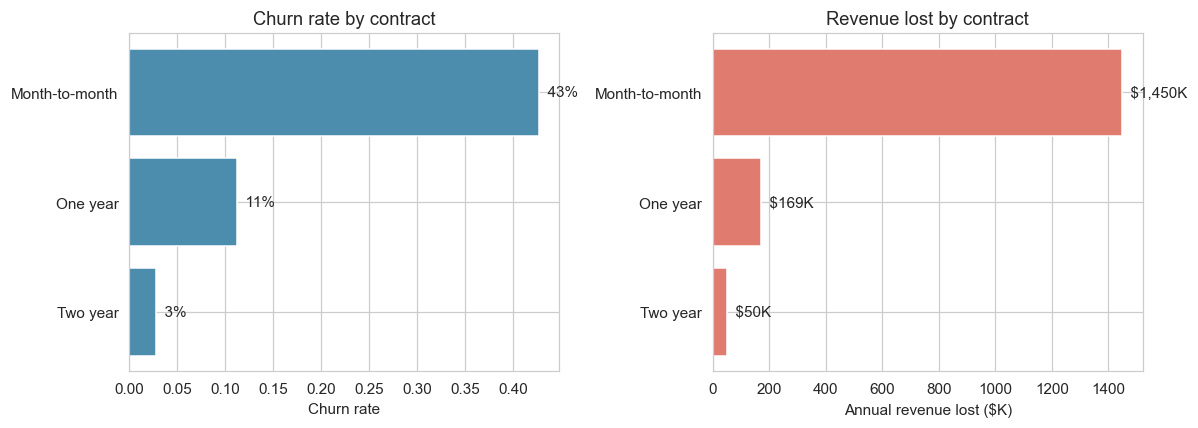

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
cs = contract_summary.sort_values('churn_rate', ascending=False)
axes[0].barh(cs.index, cs['churn_rate'], color=PRIMARY)
axes[0].set_xlabel('Churn rate')
axes[0].set_title('Churn rate by contract')
axes[0].invert_yaxis()
for i, v in enumerate(cs['churn_rate']):
    axes[0].text(v, i, f'  {v:.0%}', va='center')

cs2 = contract_summary.sort_values('annual_revenue_lost', ascending=False)
axes[1].barh(cs2.index, cs2['annual_revenue_lost'] / 1000, color=ACCENT)
axes[1].set_xlabel('Annual revenue lost ($K)')
axes[1].set_title('Revenue lost by contract')
axes[1].invert_yaxis()
for i, v in enumerate(cs2['annual_revenue_lost']):
    axes[1].text(v / 1000, i, f'  ${v/1000:,.0f}K', va='center')

plt.tight_layout()
plt.show()


**Takeaway.** Month-to-month accounts for almost all of the churn revenue loss — both because the churn rate on it is several times the next tier, and because it's the largest cohort. One- and two-year contracts churn at a fraction of the rate. **The single biggest retention lever is migrating month-to-month customers onto a fixed-term plan.** Every segment below should be read as "which month-to-month subgroup to attack first."


## 3. Tenure bucket — the first-year cliff

Subscription churn famously concentrates in the first year. Does this dataset show the same pattern?


In [5]:
tenure_bins = [0, 6, 12, 24, 48, int(df_raw['tenure'].max()) + 1]
tenure_labels = ['0-6 mo', '7-12 mo', '13-24 mo', '25-48 mo', '49+ mo']
df_raw['tenure_bucket'] = pd.cut(
    df_raw['tenure'], bins=tenure_bins, labels=tenure_labels, include_lowest=True
)

tenure_summary = segment_summary(df_raw, 'tenure_bucket').reindex(tenure_labels)
tenure_summary[display_cols].round({'churn_rate': 3, 'avg_monthly': 2, 'annual_revenue_lost': 0, 'share_of_total_loss': 3})


,customers,churn_rate,avg_monthly,annual_revenue_lost,share_of_total_loss
tenure_bucket,,,,,
0-6 mo,1481,0.529,54.74,598753.0,0.359
7-12 mo,705,0.359,58.95,228698.0,0.137
13-24 mo,1024,0.287,61.36,276980.0,0.166
25-48 mo,1594,0.204,65.93,329550.0,0.197
49+ mo,2239,0.095,73.95,235589.0,0.141


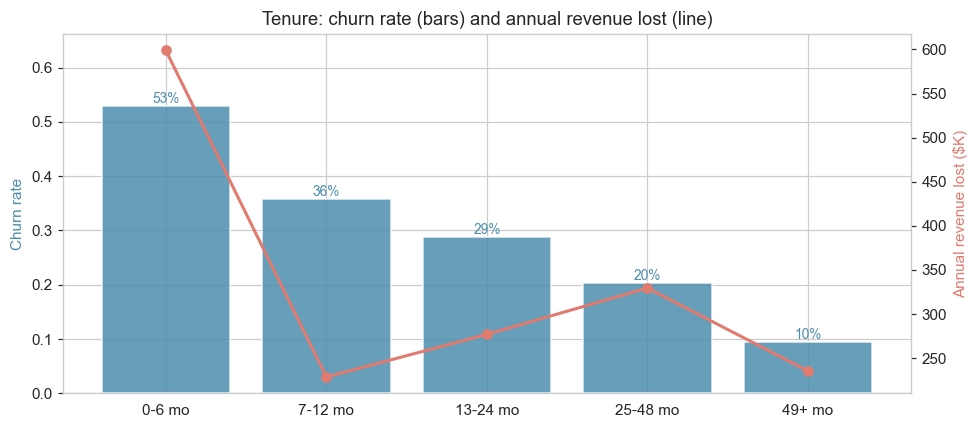

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ts = tenure_summary
x = np.arange(len(ts))

ax.bar(x, ts['churn_rate'], color=PRIMARY, alpha=0.85, label='Churn rate')
ax.set_xticks(x)
ax.set_xticklabels(ts.index)
ax.set_ylabel('Churn rate', color=PRIMARY)
ax.set_ylim(0, ts['churn_rate'].max() * 1.25)
for i, v in enumerate(ts['churn_rate']):
    ax.text(i, v, f'{v:.0%}', ha='center', va='bottom', color=PRIMARY, fontsize=9)

ax2 = ax.twinx()
ax2.plot(x, ts['annual_revenue_lost'] / 1000, color=ACCENT, marker='o', linewidth=2, label='Revenue lost ($K)')
ax2.set_ylabel('Annual revenue lost ($K)', color=ACCENT)
ax2.grid(False)

ax.set_title('Tenure: churn rate (bars) and annual revenue lost (line)')
plt.tight_layout()
plt.show()


**Takeaway.** The first-year cliff is real and sharp. Customers in their first 6 months churn at roughly double the baseline rate, and the 0–6 month bucket alone accounts for a disproportionate share of total lost revenue. After year one, churn drops fast and stays low. **Any retention program that doesn't specifically target months 1–6 is leaving the biggest lever untouched.** Onboarding quality, early-tenure offers, and proactive outreach in the first 90 days are where the money is.


## 4. Payment method

Payment method is usually a proxy for friction, not a driver in itself — customers on auto-pay already committed, and electronic-check users tend to be less engaged to start with. Quantify the gap.


In [7]:
payment_summary = segment_summary(df_raw, 'PaymentMethod').sort_values('annual_revenue_lost', ascending=False)
payment_summary[display_cols].round({'churn_rate': 3, 'avg_monthly': 2, 'annual_revenue_lost': 0, 'share_of_total_loss': 3})


,customers,churn_rate,avg_monthly,annual_revenue_lost,share_of_total_loss
PaymentMethod,,,,,
Electronic check,2365,0.453,76.26,1011465.0,0.606
Bank transfer (automatic),1544,0.167,67.19,241103.0,0.144
Credit card (automatic),1522,0.152,66.51,215359.0,0.129
Mailed check,1612,0.191,43.92,201643.0,0.121


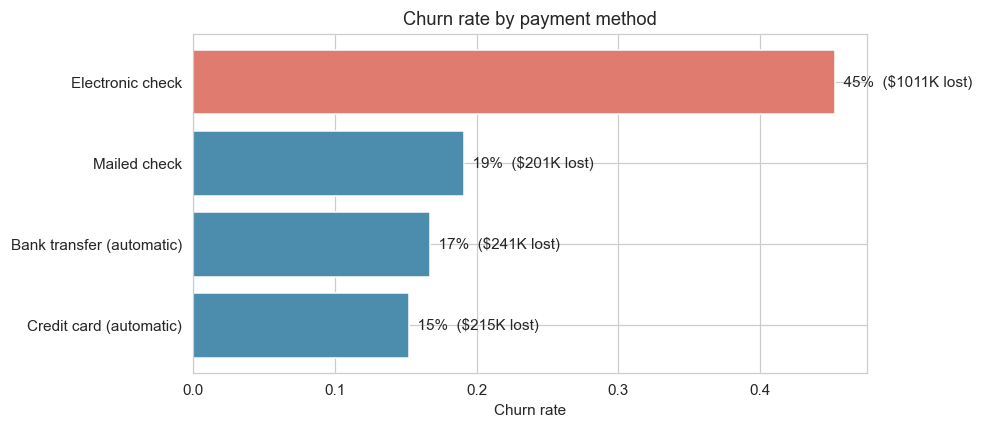

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
ps = payment_summary.sort_values('churn_rate', ascending=False)
colors = [ACCENT if 'Electronic' in i else PRIMARY for i in ps.index]
ax.barh(ps.index, ps['churn_rate'], color=colors)
ax.set_xlabel('Churn rate')
ax.set_title('Churn rate by payment method')
ax.invert_yaxis()
for i, v in enumerate(ps['churn_rate']):
    ax.text(v, i, f'  {v:.0%}  (${int(ps["annual_revenue_lost"].iloc[i]/1000)}K lost)', va='center')
plt.tight_layout()
plt.show()


**Takeaway.** Electronic check payers churn at roughly twice the rate of automatic bank transfer or credit card customers. A cheap intervention — a small credit for switching to auto-pay — could move a meaningful share of this cohort onto a stickier payment rail. This is a textbook "low-cost nudge, measurable outcome" A/B test candidate.


## 5. Service bundle — internet tier and add-ons

Two angles here: (a) which internet tier churns harder (fiber vs DSL vs none), and (b) whether customers with more add-on services (online security, tech support, streaming) stick around longer. The add-on count is a rough proxy for product engagement.


In [9]:
addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
              'TechSupport', 'StreamingTV', 'StreamingMovies']
df_raw['addon_count'] = (df_raw[addon_cols] == 'Yes').sum(axis=1)
df_raw['addon_bucket'] = pd.cut(
    df_raw['addon_count'],
    bins=[-1, 0, 2, 4, 6],
    labels=['0', '1-2', '3-4', '5-6'],
)

bundle_churn = pd.pivot_table(
    df_raw,
    index='InternetService',
    columns='addon_bucket',
    values='Churn',
    aggfunc=lambda s: (s == 'Yes').mean(),
    observed=True,
)
bundle_counts = pd.pivot_table(
    df_raw,
    index='InternetService',
    columns='addon_bucket',
    values='Churn',
    aggfunc='size',
    observed=True,
)
print('Churn rate by internet tier x add-on count:')
print(bundle_churn.round(3))
print()
print('Customer count per cell:')
print(bundle_counts.fillna(0).astype(int))


Churn rate by internet tier x add-on count:
addon_bucket         0    1-2    3-4   5-6
InternetService                           
DSL              0.412  0.260  0.114  0.04
Fiber optic      0.604  0.519  0.353  0.16
No               0.074    NaN    NaN   NaN

Customer count per cell:
addon_bucket        0   1-2   3-4  5-6
InternetService                       
DSL               294   869   834  424
Fiber optic       399  1130  1136  431
No               1526     0     0    0


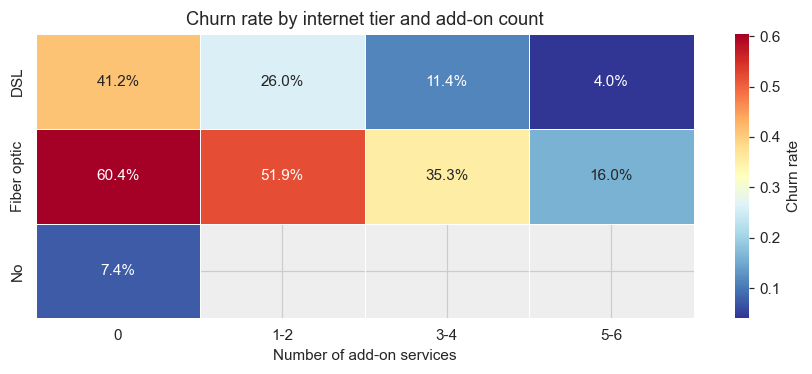

In [10]:
fig, ax = plt.subplots(figsize=(8, 3.5))
mask = bundle_churn.isna()
sns.heatmap(
    bundle_churn,
    mask=mask,
    annot=True,
    fmt='.1%',
    cmap='RdYlBu_r',
    ax=ax,
    cbar_kws={'label': 'Churn rate'},
    linewidths=0.5,
)
ax.set_title('Churn rate by internet tier and add-on count')
ax.set_xlabel('Number of add-on services')
ax.set_ylabel('')
ax.set_facecolor('#eeeeee')
plt.tight_layout()
plt.show()


**Takeaway.** Fiber-optic customers with zero add-ons are the worst-performing cell by a wide margin — high monthly charge, no product stickiness, and no contractual commitment if they're also on month-to-month. Customers with 3+ add-ons churn noticeably less regardless of internet tier, which suggests the add-ons act as switching costs even when they weren't the primary reason the customer signed up. **Bundling security + tech support into fiber plans is a structural retention play**, separate from any one-off retention offer.


## 6. Unified revenue-at-risk ranking

Pull the top drivers from all three segmentation axes into a single ranked view. This is the "where to aim retention budget first" answer.


In [11]:
ranked = pd.concat([
    contract_summary.assign(axis='Contract').reset_index().rename(columns={'Contract': 'segment'}),
    tenure_summary.assign(axis='Tenure').reset_index().rename(columns={'tenure_bucket': 'segment'}),
    payment_summary.assign(axis='Payment method').reset_index().rename(columns={'PaymentMethod': 'segment'}),
], ignore_index=True)
ranked['segment'] = ranked['segment'].astype(str)
ranked = ranked[['axis', 'segment', 'customers', 'churn_rate', 'annual_revenue_lost', 'share_of_total_loss']]
ranked = ranked.sort_values('annual_revenue_lost', ascending=False).head(10).reset_index(drop=True)
ranked.round({'churn_rate': 3, 'annual_revenue_lost': 0, 'share_of_total_loss': 3})


,axis,segment,customers,churn_rate,annual_revenue_lost,share_of_total_loss
0,Contract,Month-to-month,3875,0.427,1450165.0,0.869
1,Payment method,Electronic check,2365,0.453,1011465.0,0.606
2,Tenure,0-6 mo,1481,0.529,598753.0,0.359
3,Tenure,25-48 mo,1594,0.204,329550.0,0.197
4,Tenure,13-24 mo,1024,0.287,276980.0,0.166
5,Payment method,Bank transfer (automatic),1544,0.167,241103.0,0.144
6,Tenure,49+ mo,2239,0.095,235589.0,0.141
7,Tenure,7-12 mo,705,0.359,228698.0,0.137
8,Payment method,Credit card (automatic),1522,0.152,215359.0,0.129
9,Payment method,Mailed check,1612,0.191,201643.0,0.121


The ranking confirms what each section showed individually: month-to-month contracts, first-year tenure, and electronic check payment all surface near the top. These cohorts **overlap heavily** in the real data — a typical high-risk customer is month-to-month, 0–12 months in, paying by electronic check, on fiber with no add-ons. That overlap is exactly what the model in section 7 is going to exploit.


## 7. Top 100 at-risk active customers

Descriptive segmentation tells us *where* churn concentrates. The model tells us *who specifically* to call this week. Score every customer with honest out-of-fold XGBoost predictions (5-fold CV so no customer is scored by a model that saw them during training), then filter to currently-active customers and rank by predicted churn probability.

Hyperparameters match the final XGBoost in the modeling notebook so the two notebooks stay in sync.


In [12]:
df_model = preprocess_data(
    df_raw.drop(columns=['tenure_bucket', 'addon_count', 'addon_bucket']).copy(),
    target_col='Churn',
)
df_enc = build_features(df_model, target_col='Churn')
X = df_enc.drop(columns=['Churn'])
y = df_enc['Churn'].astype(int)

scale_pos_weight = (y == 0).sum() / (y == 1).sum()

oof_model = XGBClassifier(
    n_estimators=301,
    learning_rate=0.034,
    max_depth=7,
    subsample=0.95,
    colsample_bytree=0.98,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
proba_oof = cross_val_predict(oof_model, X, y, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]

print(f'Out-of-fold predictions generated for {len(proba_oof):,} customers.')


Starting feature engineering on 20 columns...
  Found 15 categorical and 5 numeric columns
Feature engineering complete: 31 final features


Out-of-fold predictions generated for 7,043 customers.


In [13]:
scored = df_raw[[
    'customerID', 'Contract', 'tenure', 'tenure_bucket', 'PaymentMethod',
    'InternetService', 'addon_count', 'MonthlyCharges', 'Churn'
]].copy()
scored['churn_probability'] = proba_oof
scored['annual_revenue_at_risk'] = scored['MonthlyCharges'] * 12 * scored['churn_probability']

active = scored[scored['Churn'] == 'No'].copy()
top_100 = active.sort_values('churn_probability', ascending=False).head(100).reset_index(drop=True)

print(f'Active customers scored:       {len(active):,}')
print(f'Top 100 probability range:     {top_100["churn_probability"].min():.1%} - {top_100["churn_probability"].max():.1%}')
print(f'Top 100 annual $ at risk:      ${top_100["annual_revenue_at_risk"].sum():,.0f}')
print(f'Mean MonthlyCharges (top 100): ${top_100["MonthlyCharges"].mean():.2f}')
print()
print('Preview of the list the retention team would receive:')
top_100.head(10)[[
    'customerID', 'Contract', 'tenure', 'PaymentMethod', 'InternetService',
    'MonthlyCharges', 'churn_probability', 'annual_revenue_at_risk'
]]


Active customers scored:       5,174
Top 100 probability range:     88.5% - 97.9%
Top 100 annual $ at risk:      $85,460
Mean MonthlyCharges (top 100): $77.25

Preview of the list the retention team would receive:


,customerID,Contract,tenure,PaymentMethod,InternetService,MonthlyCharges,churn_probability,annual_revenue_at_risk
0,2254-DLXRI,Month-to-month,1,Mailed check,Fiber optic,79.15,0.979283,930.123366
1,7439-DKZTW,Month-to-month,1,Electronic check,Fiber optic,80.55,0.977870,945.208727
2,1452-VOQCH,Month-to-month,1,Electronic check,Fiber optic,75.10,0.975682,879.284851
3,4912-PIGUY,Month-to-month,1,Electronic check,Fiber optic,84.60,0.970848,985.604732
4,0021-IKXGC,Month-to-month,1,Electronic check,Fiber optic,72.10,0.968999,838.377650
5,5150-ITWWB,Month-to-month,3,Electronic check,Fiber optic,94.85,0.968965,1102.876092
6,3878-AVSOQ,Month-to-month,1,Electronic check,Fiber optic,71.25,0.968734,828.267286
7,1393-IMKZG,Month-to-month,1,Electronic check,Fiber optic,95.85,0.967493,1112.810926
8,7577-SWIFR,Month-to-month,1,Electronic check,Fiber optic,89.25,0.966954,1035.607726
9,5542-TBBWB,Month-to-month,1,Electronic check,Fiber optic,69.90,0.965468,809.834950


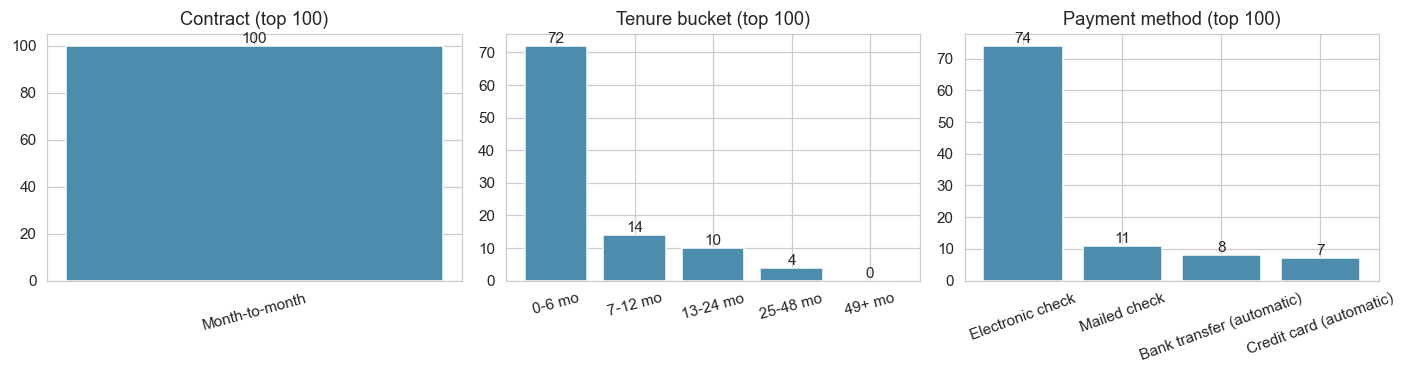

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

seg_contract = top_100['Contract'].value_counts()
axes[0].bar(seg_contract.index, seg_contract.values, color=PRIMARY)
axes[0].set_title('Contract (top 100)')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(seg_contract.values):
    axes[0].text(i, v, str(v), ha='center', va='bottom')

seg_tenure = top_100['tenure_bucket'].value_counts().reindex(tenure_labels).fillna(0)
axes[1].bar(seg_tenure.index.astype(str), seg_tenure.values, color=PRIMARY)
axes[1].set_title('Tenure bucket (top 100)')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(seg_tenure.values):
    axes[1].text(i, v, str(int(v)), ha='center', va='bottom')

seg_payment = top_100['PaymentMethod'].value_counts()
axes[2].bar(seg_payment.index, seg_payment.values, color=PRIMARY)
axes[2].set_title('Payment method (top 100)')
axes[2].tick_params(axis='x', rotation=20)
for i, v in enumerate(seg_payment.values):
    axes[2].text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()


The top 100 list is not random — it clusters tightly into the same cohorts the segmentation analysis flagged: month-to-month, short tenure, electronic check. Which means the model and the descriptive analysis are telling the same story from two directions. **This is the ranked, actionable version of sections 2–5.**


## 8. Retention action recommendations

Translating the analysis above into specific things the retention team could do tomorrow. Each row is a segment, a trigger condition, a suggested action, and the rough rationale. Cost/benefit assumptions match `02_model_analysis.ipynb` (\$50 retention offer, ~\$1,550 LTV loss per saved churn, 40% save rate).

| # | Segment | Trigger | Action | Why it should work |
|---|---|---|---|---|
| 1 | Month-to-month, tenure 1–6 months | Enrolled in the last 6 months, no contract | Offer a 12-month contract with the first month free | Converts the highest-churn, highest-volume cohort to a locked-in tier. Each conversion is worth roughly \$1,550 in avoided LTV loss minus \$50 in offer cost. |
| 2 | Fiber optic, 0 add-ons, any tenure | Fiber customer with no security/support/backup attached | Bundle OnlineSecurity + TechSupport at a small monthly discount | Fiber-with-no-addons is the worst-performing cell in the heatmap. Add-ons act as switching costs and the gross margin on them is high. |
| 3 | Electronic check payers | PaymentMethod = Electronic check | One-time \$10 credit for switching to automatic bank transfer or credit card | Cheap nudge. Auto-pay customers churn at roughly half the rate. Even if only 20% accept, the cohort-level churn rate drops materially. |
| 4 | Month-to-month, tenure 7–12 months, low engagement | Close to the first-year mark with 0–1 add-ons | Proactive check-in call + loyalty offer before the renewal decision | These customers are about to make a stay-or-leave call. A touchpoint before that moment is cheaper than a save-offer after they've already called to cancel. |
| 5 | Top 100 scored list (section 7) | `churn_probability` in the top 100 | Route directly to senior retention specialists, not the general queue | The model picks up combinations of signals the segment-level rules miss. Individual-level ranking on top of the segment plays means high-value customers don't fall through the cracks while a broader campaign is still ramping up. |

**How to measure this.** Pick one action, run it as an A/B test against a holdout of the same segment, measure 90-day retention and revenue per customer rather than raw churn-flag rates (retention offers can convert a churn into a downgrade, which is still a loss). The model's scored list is also the obvious holdout stratification variable — group assignments should be balanced on predicted probability, not just on segment.

**What this notebook does not do.** This is descriptive analysis and ranked targeting, not causal inference. "Month-to-month customers churn more" is a correlation; whether forcing contracts on them actually reduces total churn depends on selection effects that only a proper experiment can separate. The retention recommendations above should be read as hypotheses to test, not conclusions.


## 9. Generalizing to other subscription and recurring-revenue businesses

The segments above are labeled in telco terms, but the axes carry over to any subscription or recurring-revenue retention problem — SaaS, subscription media, membership businesses, consumer neobanks and subscription-fintech apps, B2B payment platforms, wallet apps. The table below gives the most direct mappings.

| This project (telco churn) | Subscription-business analog |
|---|---|
| Month-to-month vs. annual contract | Month-to-month vs. annual subscription (any recurring product or plan) |
| Tenure (months on service) | Customer relationship length |
| Payment method | Funding instrument / auto-pay enrollment |
| Service bundle (internet + phone + add-ons) | Plan tier, product holdings, or feature adoption |
| MonthlyCharges | MRR, ARPU, or net per-customer revenue per period |
| Annual revenue at risk | Annualized revenue at risk given predicted attrition |
| Top-N at-risk list | Prioritized retention or customer-success outreach list |

The recurring-revenue shape is what makes the analysis transfer: periodic billing, commitment levels that correlate with attrition, behavioral engagement signals, and a downstream operational team working a ranked outreach list. Fintech retention (neobank attrition, card inactivity, wallet churn), SaaS churn, subscription media, and B2B platform retention all sit inside this family.

The segmentation → revenue-at-risk → ranked-outreach pipeline in sections 2-7 is domain-agnostic. Only the feature labels, dollar units, and recommended retention actions need domain-specific wording.
